# Per-Event Storm Tracking

Visualize the **spatiotemporal evolution + fitted ellipse** of a *single* storm event:
a storm-track overview (centroid trajectory, ellipses, mean-direction vector) and a grid
of per-time-step rainfall panels.

Same thing from the command line:
```bash
python run_diagnostics.py event --config configs/testing_data.json --storm 100
```

In [1]:
# Make the package importable and pick up code edits without a manual kernel restart:
# chdir to the repo root, then drop cached stormcatalog_analyzer modules so the imports
# below are re-read fresh from disk on every re-run.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]
print("repo root:", root)

repo root: /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo


## 1. Load config and choose a storm

In [5]:
from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline

cfg = load_config("configs/testing_data.json")

# A storm filename, a unique substring, or a numeric storm id:
storm = "380"

## 2. Track the event and render its figures
Saved under `<output_dir>/<domain>/StormTrack/` and `.../StormTimeSteps/`.

In [6]:
figs = pipeline.generate_event_diagnostics(cfg, storm)

The longest storm has a valid duration of 24 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2004-10-20T03:00:00.000000000 to 2004-10-21T02:00:00.000000000
Selected storm duration 24 hours


/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/stormcatalog_analyzer/motion/direction.py:228: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window = pd.to_timedelta(window)


Saved 2 figures for IOWA_Domain.nc_storm_380_20041020.nc:
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTrack/storm_track_380.png
  /Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer repo/testing_data/Test Domain/StormTimeSteps/storm_step_380.png


## 3. Display

storm_track_380.png


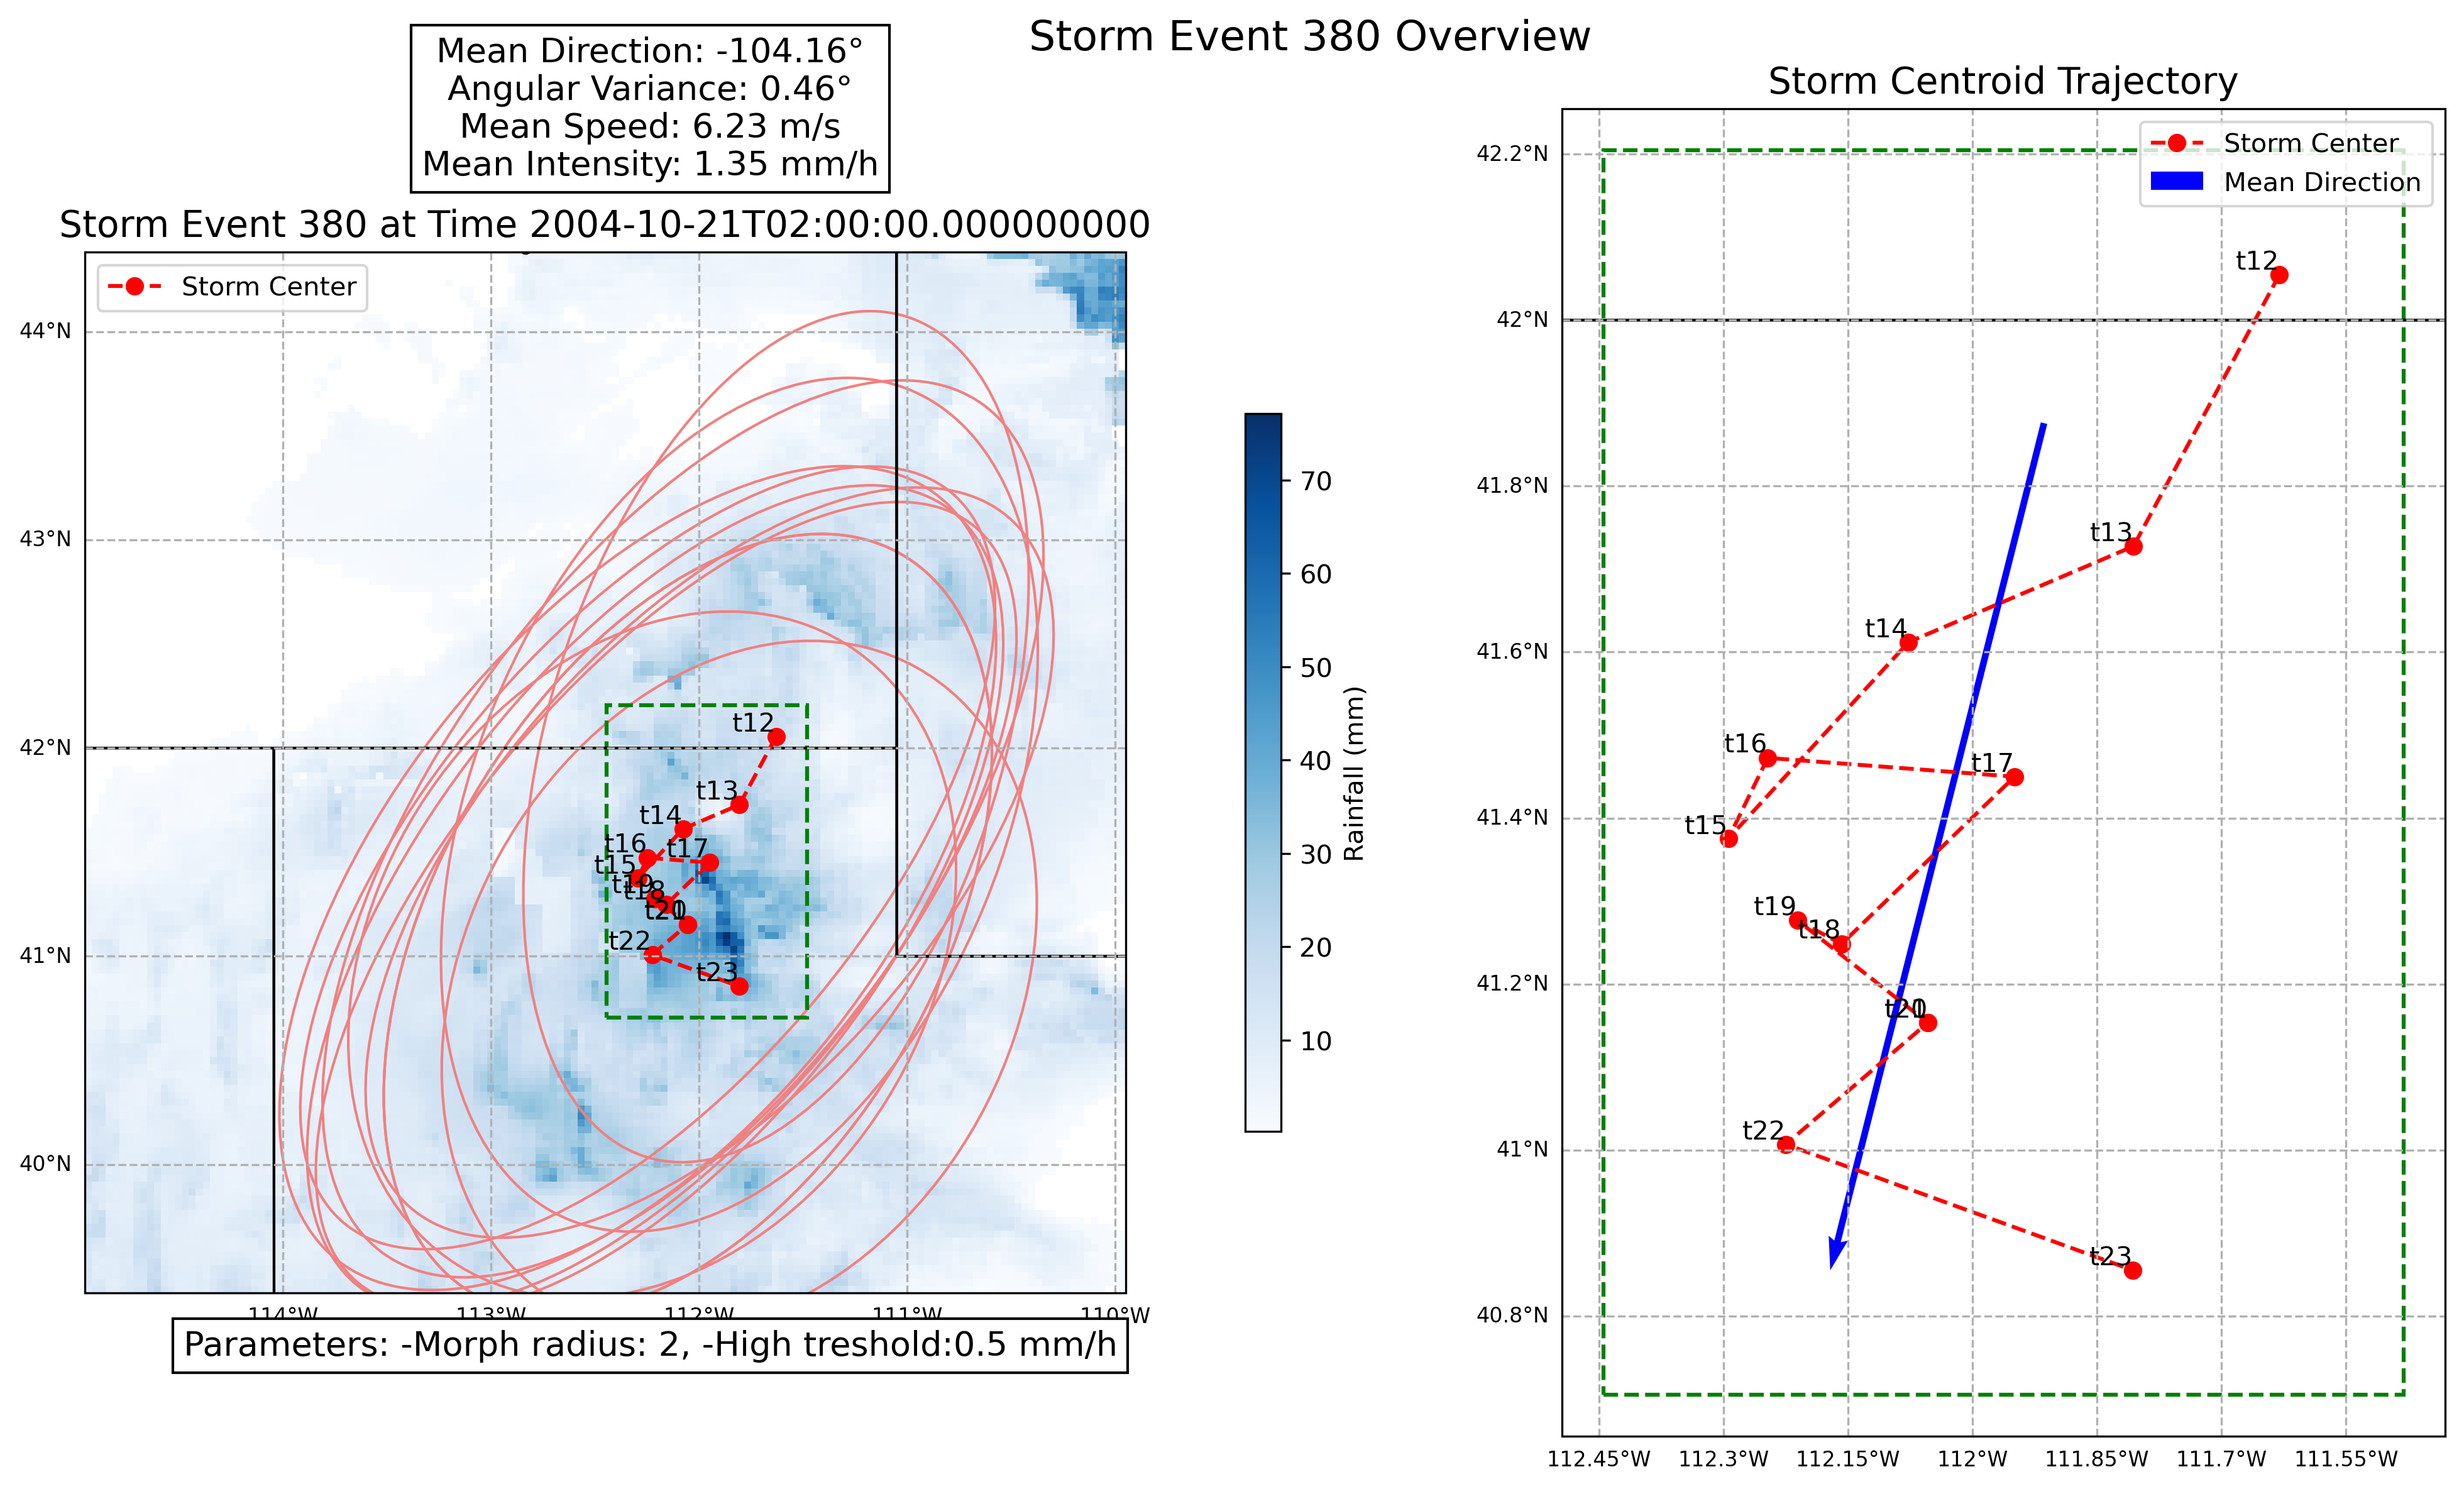

storm_step_380.png


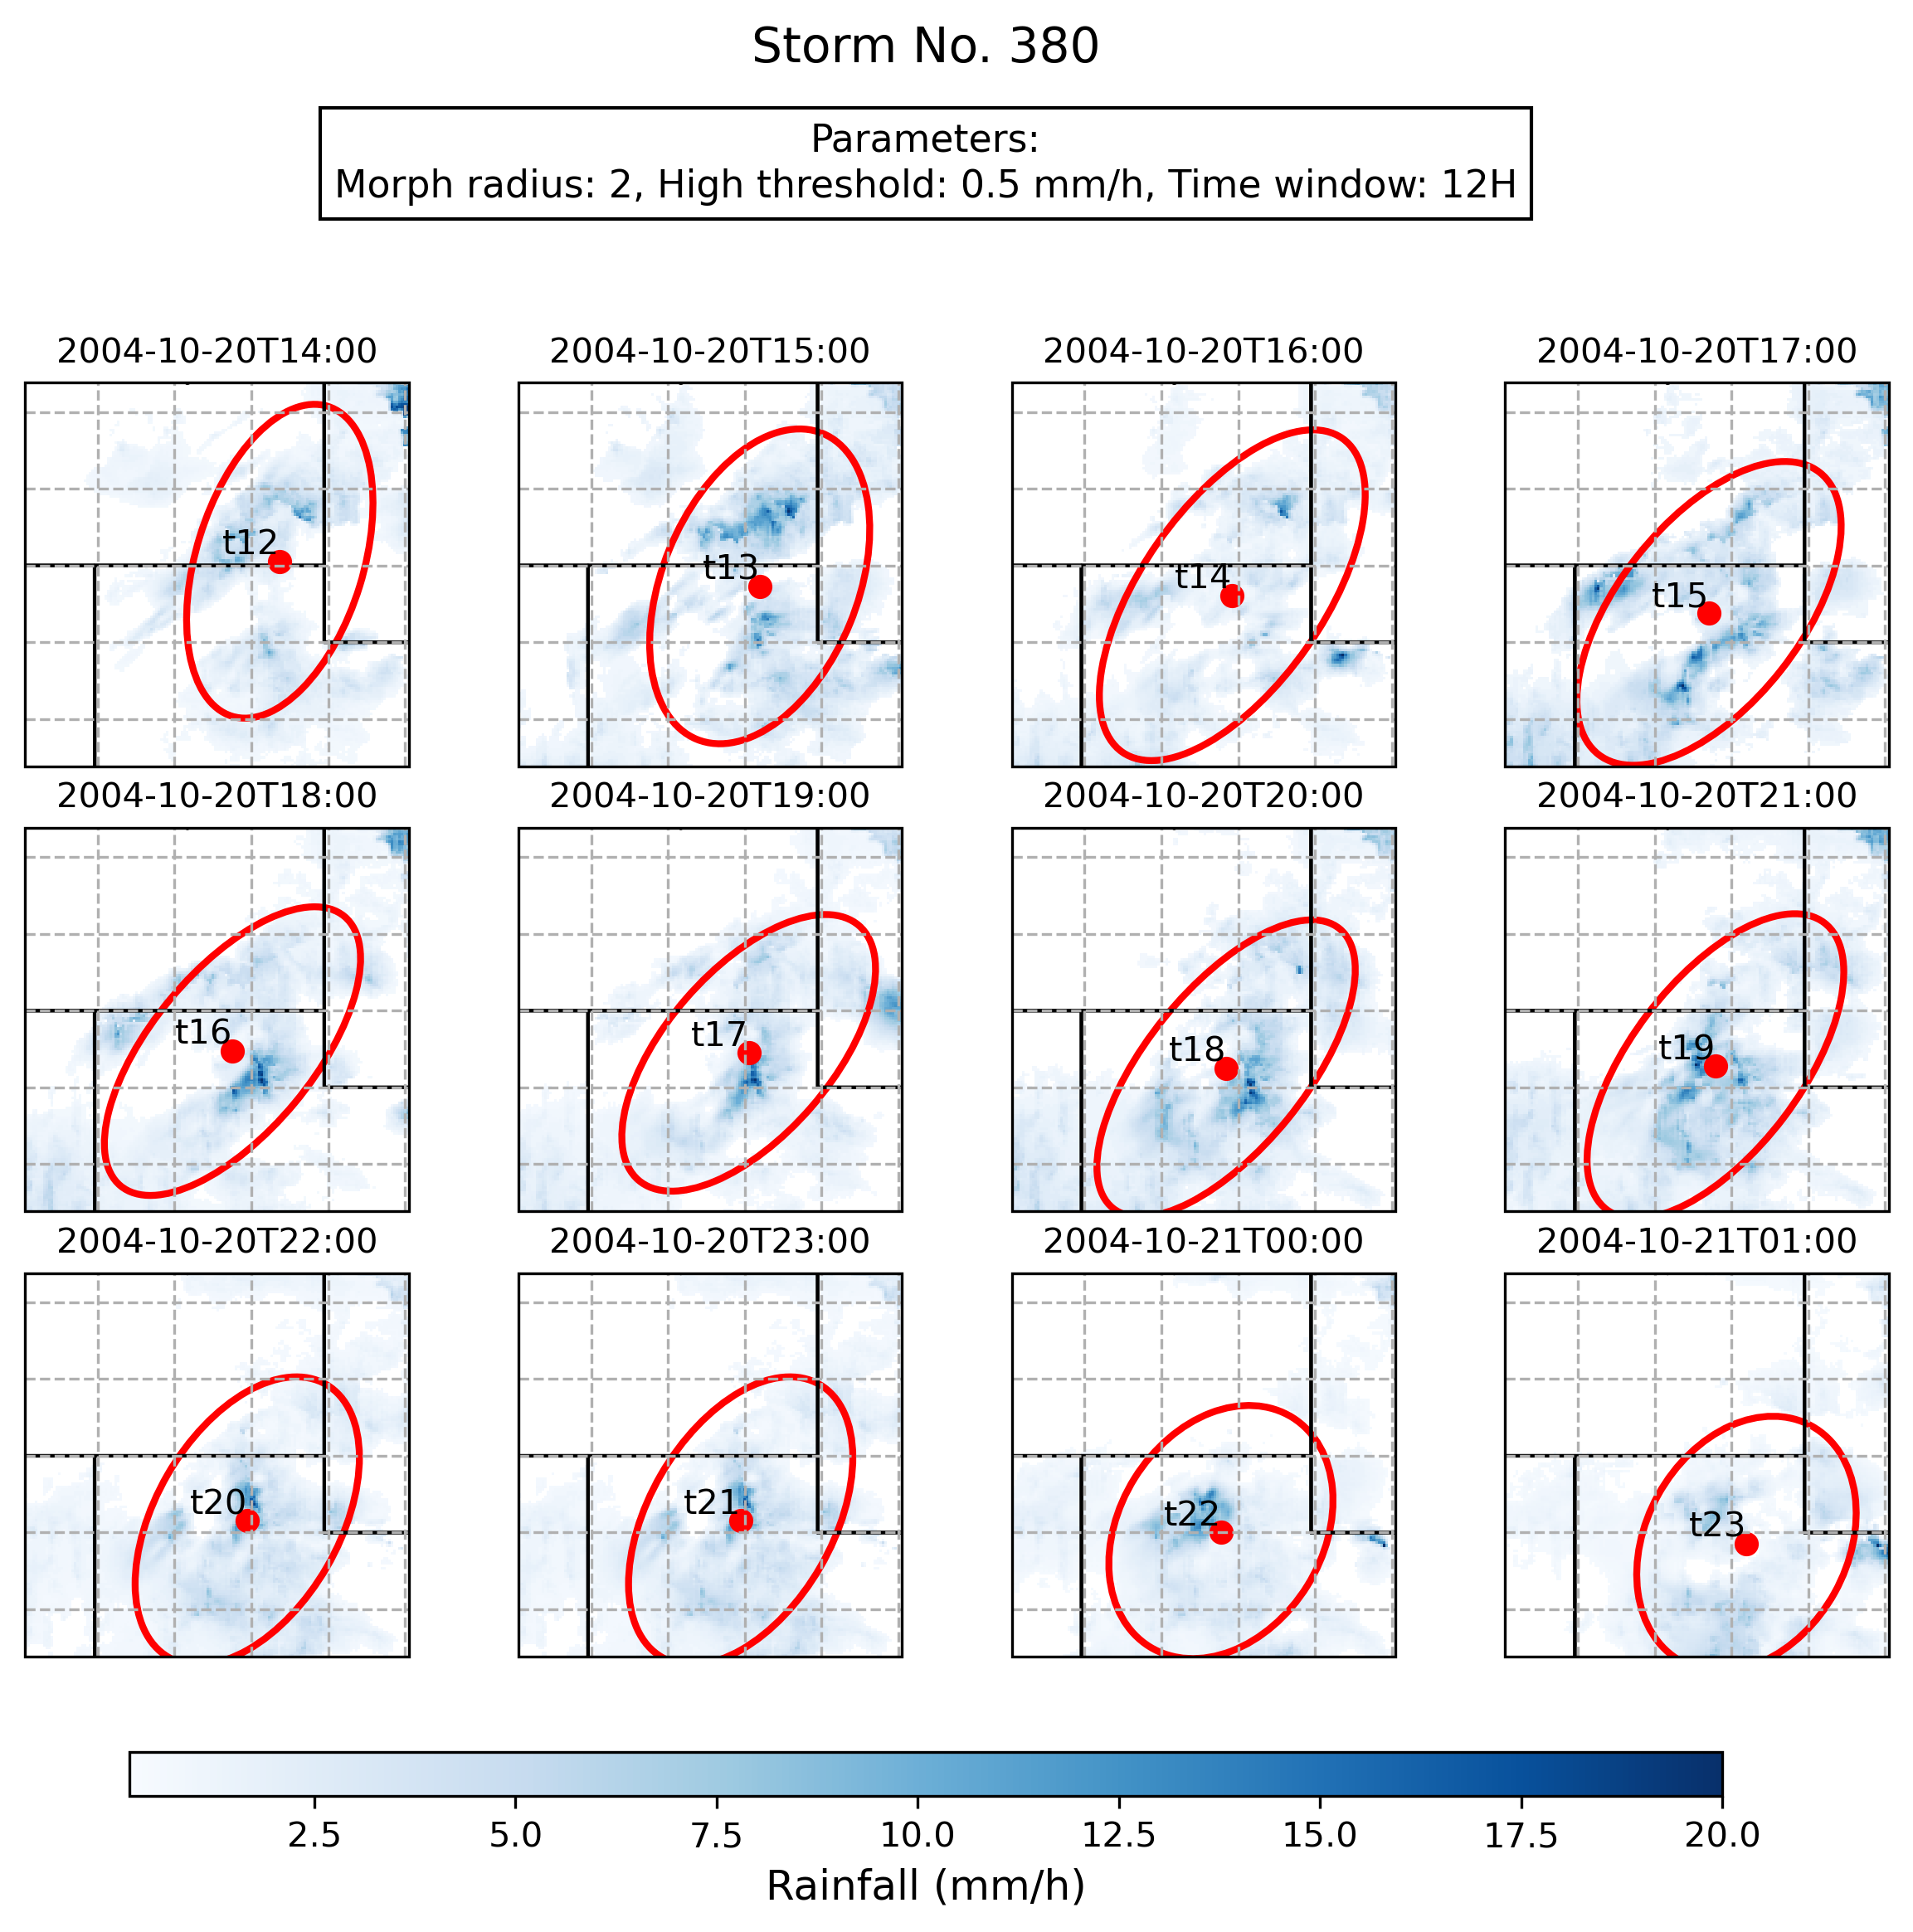

In [7]:
from IPython.display import Image, display
for p in figs:
    print(p.name)
    display(Image(filename=str(p)))